# Imports and configs

In [28]:
import numpy as np
import cv2
import pandas as pd
import glob
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# Utils

# Image features extraction methods

In [ ]:
def compute_contrast(image):
    """Michelson contrast - miara kontrastu"""
    i_min = image.min()
    i_max = image.max()
    contrast = (i_max - i_min) / (i_max + i_min + 1e-6)
    return contrast

def compute_brenner_gradient(image):
    """Brenner gradient - miara ostrości"""
    # Gradient w kierunku x
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
    brenner = np.sum(gx**2)
    return brenner

def compute_laplacian_sum(image):
    """Suma wartości Laplacian'a"""
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    return np.sum(np.abs(laplacian))

def compute_laplacian_variance(image):
    """Wariancja Laplacian'a - czułość na rozmycie"""
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    variance = laplacian.var()
    return variance

def compute_power_spectrum_ratio(image):
    """Ratio mocy wysokich vs niskich częstotliwości"""
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    
    h, w = magnitude.shape
    center_h, center_w = h // 2, w // 2
    
    low_freq = np.mean(magnitude[center_h-20:center_h+20, center_w-20:center_w+20])
    
    high_freq = (np.mean(magnitude[:30, :30]) + 
                 np.mean(magnitude[-30:, -30:]) + 
                 np.mean(magnitude[:30, -30:]) + 
                 np.mean(magnitude[-30:, :30])) / 4
    
    ratio = high_freq / (low_freq + 1e-6)
    return ratio

def compute_entropy(image):
    """Entropia Shannon'a histogramu"""
    hist, _ = np.histogram(image, bins=256, range=(0, 256))
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))
    return entropy

def compute_harris_corners(image):
    """Ilość narożników Harris'a"""
    gray = image.astype(np.float32)
    corners = cv2.cornerHarris(gray, 2, 3, 0.04)
    corner_count = np.sum(corners > 0.01 * corners.max())
    return corner_count

def compute_gradient_energy(image):
    """Energia gradientu - suma kwadratów gradientów"""
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    gradient_energy = np.sum(sobelx**2 + sobely**2)
    return gradient_energy

def compute_histogram_properties(image):
    """Skośność i kurtoza histogramu"""
    hist, _ = np.histogram(image, bins=256, range=(0, 256))
    
    # Średnia i std
    mean = np.average(np.arange(256), weights=hist)
    std = np.sqrt(np.average((np.arange(256) - mean)**2, weights=hist))
    
    # Skośność
    skewness = np.average((np.arange(256) - mean)**3, weights=hist) / (std**3 + 1e-6)
    
    # Kurtoza
    kurtosis = np.average((np.arange(256) - mean)**4, weights=hist) / (std**4 + 1e-6)
    
    return skewness, kurtosis

def compute_log(image):
    """Laplacian of Gaussian - średnia wartość"""
    log = cv2.GaussianBlur(image, (5, 5), 0)
    log = cv2.Laplacian(log, cv2.CV_64F)
    log_abs = cv2.convertScaleAbs(log)
    mean_log = np.mean(log_abs)
    return mean_log

def compute_fft(image):
    """FFT - średnia mocy niskich i wysokich częstotliwości"""
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    
    # Średnia moc w wyższych częstotliwościach
    low_freq_magnitude = np.mean(magnitude[:int(magnitude.shape[0]/2), :int(magnitude.shape[1]/2)])
    high_freq_magnitude = np.mean(magnitude[int(magnitude.shape[0]/2):, int(magnitude.shape[1]/2):])
    
    return low_freq_magnitude, high_freq_magnitude

def compute_canny(image):
    """Canny edge detection - liczba krawędzi"""
    edges = cv2.Canny(image, 100, 200)
    edge_count = np.sum(edges == 255)
    return edge_count

def compute_histogram_variance(image):
    """Wariancja histogramu"""
    hist, _ = np.histogram(image, bins=256, range=(0, 256))
    hist = hist / hist.sum()
    mean = np.sum(np.arange(256) * hist)
    variance = np.sum((np.arange(256) - mean)**2 * hist)
    return variance

def compute_gradient_variance(image):
    """Wariancja magnitudy gradientu"""
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.var(magnitude)

def compute_local_variance(image, window_size=5):
    """Średnia lokalna wariancja (tekstura)"""
    local_var = cv2.blur(image**2, (window_size, window_size)) - \
                (cv2.blur(image, (window_size, window_size))**2)
    return np.mean(local_var)

def compute_edge_density(image):
    """Gęstość krawędzi (% pikseli będących krawędziami)"""
    edges = cv2.Canny(image, 50, 150)
    density = np.sum(edges > 0) / edges.size
    return density

In [ ]:
def extract_features(image):
    """Ekstrakcja wszystkich cech"""

    mean_log = compute_log(image)
    low_freq_magnitude, high_freq_magnitude = compute_fft(image)
    edge_count = compute_canny(image)
    
    laplacian_var = compute_laplacian_variance(image)
    laplacian_sum = compute_laplacian_sum(image)

    power_ratio = compute_power_spectrum_ratio(image)

    entropy = compute_entropy(image)
    histogram_variance = compute_histogram_variance(image)
    skewness, kurtosis = compute_histogram_properties(image)

    harris_corners = compute_harris_corners(image)
    gradient_energy = compute_gradient_energy(image)
    gradient_variance = compute_gradient_variance(image)

    contrast = compute_contrast(image)
    brenner_gradient = compute_brenner_gradient(image)
    edge_density = compute_edge_density(image)
    local_variance = compute_local_variance(image)
    
    return [
        mean_log, low_freq_magnitude, high_freq_magnitude, edge_count,     
        laplacian_var, laplacian_sum, power_ratio,                      
        entropy, histogram_variance, skewness, kurtosis,                        
        harris_corners, gradient_energy, gradient_variance,                 
        contrast, brenner_gradient, edge_density, local_variance                
    ]

## Test

In [6]:
img = cv2.imread('../data/gopro_deblur/blur/images/000001.png')

In [7]:
compute_laplacian_variance(img)

np.float64(15.001649282037343)

# Extraction

## Blur images

In [42]:
feature_names = [
    'mean_log', 'low_freq', 'high_freq', 'edge_count',
    'laplacian_var', 'laplacian_sum', 'power_ratio',
    'entropy', 'histogram_variance', 'skewness', 'kurtosis',
    'harris_corners', 'gradient_energy', 'gradient_variance',
    'contrast', 'brenner_gradient', 'edge_density', 'local_variance'
]

In [43]:
blur_features = []
blur_labels = []

for path in tqdm(glob.glob('../data/gopro_deblur/blur/images/*.png')):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is not None:
        features = extract_features(image)
        blur_features.append(features)
        blur_labels.append(1)  # 1 = blur

 10%|▉         | 100/1029 [00:25<03:50,  4.04it/s]C:\Users\Łukasz\AppData\Local\Temp\ipykernel_35644\1002973095.py:5: RuntimeWarning: overflow encountered in scalar add
  contrast = (i_max - i_min) / (i_max + i_min + 1e-6)
100%|██████████| 1029/1029 [04:45<00:00,  3.60it/s]


In [44]:
df_blur = pd.DataFrame(blur_features, columns=feature_names)

In [45]:
del blur_features, blur_labels

In [46]:
sharp_features = []
sharp_labels = []

for path in tqdm(glob.glob('../data/gopro_deblur/sharp/images/*.png')):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is not None:
        features = extract_features(image)
        sharp_features.append(features)
        sharp_labels.append(0)  # 0 = sharp

 10%|▉         | 100/1029 [00:26<04:08,  3.74it/s]C:\Users\Łukasz\AppData\Local\Temp\ipykernel_35644\1002973095.py:5: RuntimeWarning: overflow encountered in scalar add
  contrast = (i_max - i_min) / (i_max + i_min + 1e-6)
100%|██████████| 1029/1029 [05:18<00:00,  3.23it/s]


In [47]:
df_sharp = pd.DataFrame(sharp_features, columns=feature_names)

In [48]:
del sharp_features, sharp_labels

In [51]:
df_blur['image_type'] = 'blur'
df_blur['label'] = 1

df_sharp['image_type'] = 'sharp'
df_sharp['label'] = 0

In [52]:
df_blur = df_blur.reset_index().rename(columns={'index': 'id'})

In [53]:
df_sharp = df_sharp.reset_index().rename(columns={'index': 'id'})

In [54]:
df_blur.shape, df_sharp.shape

((1029, 21), (1029, 21))

In [55]:
df = pd.concat([
    df_sharp,
    df_blur
], ignore_index=True)

In [56]:
df.shape

(2058, 21)

In [57]:
df.head()

,id,mean_log,low_freq,high_freq,edge_count,laplacian_var,laplacian_sum,power_ratio,entropy,histogram_variance,...,kurtosis,harris_corners,gradient_energy,gradient_variance,contrast,brenner_gradient,edge_density,local_variance,image_type,label
0,0,2.478630,7739.515356,8800.253613,28622,185.186727,4929304.0,0.001245,7.534464,5190.076294,...,2.806116,2185,6.060234e+09,5563.225750,1.0,4.142813e+11,0.039901,117.885913,sharp,0
1,1,2.483279,7722.263969,8819.858668,28765,186.324475,4928116.0,0.001224,7.533717,5236.192935,...,2.789284,2017,6.115188e+09,5616.376095,1.0,4.142132e+11,0.040581,117.611967,sharp,0
2,2,2.516513,7819.178449,8922.411645,29277,197.533175,5372334.0,0.001427,7.537010,5177.655336,...,2.822678,1659,6.163315e+09,5635.900886,1.0,4.214159e+11,0.041434,118.307733,sharp,0
3,3,2.510142,7742.388298,8840.171875,29538,190.854369,5217539.0,0.001482,7.536990,5078.126087,...,2.877975,2167,6.141492e+09,5621.258628,1.0,4.234586e+11,0.041101,118.406325,sharp,0
4,4,2.490413,7737.686199,8832.781117,28536,193.846921,5206308.0,0.001511,7.533639,4943.817762,...,2.952369,2910,6.093219e+09,5584.585510,1.0,4.235255e+11,0.040216,118.376377,sharp,0


In [62]:
df.drop(['id', 'image_type'], axis=1).corr()

,mean_log,low_freq,high_freq,edge_count,laplacian_var,laplacian_sum,power_ratio,entropy,histogram_variance,skewness,kurtosis,harris_corners,gradient_energy,gradient_variance,contrast,brenner_gradient,edge_density,local_variance,label
mean_log,1.000000,0.956243,0.959844,0.982639,0.943723,0.976283,0.587348,0.323932,0.365258,0.319167,-0.197672,0.454244,0.973556,0.931097,0.051556,0.935237,0.971234,0.307345,-0.688601
low_freq,0.956243,1.000000,0.997662,0.929989,0.919548,0.938668,0.601514,0.348062,0.385256,0.312219,-0.199943,0.357904,0.958565,0.947998,0.052941,0.919367,0.906887,0.299929,-0.752173
high_freq,0.959844,0.997662,1.000000,0.932934,0.925032,0.943002,0.607914,0.352791,0.413862,0.314805,-0.211094,0.374105,0.961807,0.949846,0.047935,0.918268,0.911406,0.291701,-0.744489
edge_count,0.982639,0.929989,0.932934,1.000000,0.928856,0.964669,0.591353,0.306555,0.320190,0.283337,-0.181001,0.436893,0.942842,0.889792,0.057511,0.894708,0.984344,0.282170,-0.667598
laplacian_var,0.943723,0.919548,0.925032,0.928856,1.000000,0.974099,0.744866,0.157366,0.355699,0.261708,-0.118792,0.464480,0.958127,0.941029,0.031789,0.881025,0.884394,0.150694,-0.763957
laplacian_sum,0.976283,0.938668,0.943002,0.964669,0.974099,1.000000,0.696557,0.230368,0.311903,0.255867,-0.148403,0.470250,0.947419,0.910329,0.046757,0.894374,0.947907,0.219100,-0.779920
power_ratio,0.587348,0.601514,0.607914,0.591353,0.744866,0.696557,1.000000,-0.150261,0.190622,0.084122,-0.002664,0.273719,0.603406,0.624652,-0.014386,0.464986,0.549124,-0.099114,-0.703188
entropy,0.323932,0.348062,0.352791,0.306555,0.157366,0.230368,-0.150261,1.000000,0.526385,0.321867,-0.523287,-0.037126,0.301733,0.276109,0.019480,0.407456,0.338303,0.698972,-0.063201
histogram_variance,0.365258,0.385256,0.413862,0.320190,0.355699,0.311903,0.190622,0.526385,1.000000,0.572911,-0.338569,0.148583,0.457311,0.483811,-0.071092,0.421923,0.304387,0.218826,-0.161118
skewness,0.319167,0.312219,0.314805,0.283337,0.261708,0.255867,0.084122,0.321867,0.572911,1.000000,0.149361,0.312189,0.358088,0.345173,-0.015804,0.326579,0.302623,0.470082,-0.006344


<Axes: xlabel='laplacian_var', ylabel='Density'>

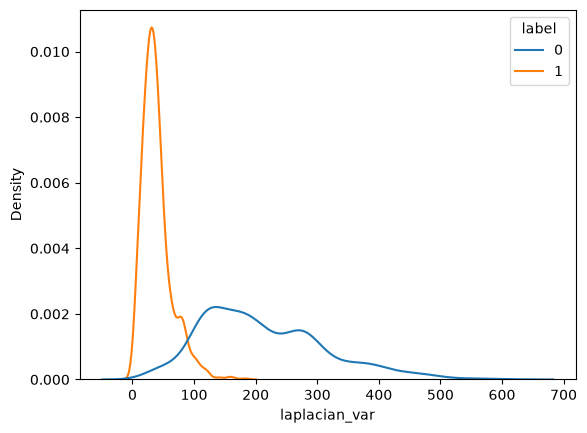

In [ ]:
sns.kdeplot(data=df, x='laplacian_var', hue='label')

In [97]:
image = cv2.imread('../data/images.jpeg', cv2.IMREAD_GRAYSCALE)

In [98]:
image

array([[ 2,  2,  2, ...,  1,  1,  1],
       [ 2,  2,  2, ...,  1,  1,  1],
       [ 2,  2,  2, ...,  1,  1,  1],
       ...,
       [20, 17, 19, ..., 17, 17, 17],
       [22, 17, 17, ..., 17, 17, 17],
       [26, 18, 15, ..., 17, 17, 17]], shape=(183, 275), dtype=uint8)

In [99]:
extract_features(image)

[np.float64(4.275529061102832),
 np.float64(3491.0654959389317),
 np.float64(4424.532397168741),
 np.int64(3715),
 np.float64(1348.4209829100414),
 np.float64(652924.0),
 np.float64(0.014169399559338098),
 np.float64(7.245024582131007),
 np.float64(5451.9854292134405),
 np.float64(0.37770435073858244),
 np.float64(1.5956262158145877),
 np.int64(540),
 np.float64(849666778.0),
 np.float64(12399.285930359727),
 np.float64(0.9999999960784314),
 np.float64(79556986516.0),
 np.float64(0.09341281669150521),
 np.float64(112.06410332836562)]

# Additional features

In [102]:
def compute_tenengrad(image):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    grad = np.sqrt(gx**2 + gy**2)

    return np.mean(grad**2)

In [109]:
image

array([[ 2,  2,  2, ...,  1,  1,  1],
       [ 2,  2,  2, ...,  1,  1,  1],
       [ 2,  2,  2, ...,  1,  1,  1],
       ...,
       [20, 17, 19, ..., 17, 17, 17],
       [22, 17, 17, ..., 17, 17, 17],
       [26, 18, 15, ..., 17, 17, 17]], shape=(183, 275), dtype=uint8)

In [103]:
compute_tenengrad(image)

np.float64(16883.5922106309)

In [105]:
import pywt

def compute_wavelet_energy(image):
    coeffs = pywt.dwt2(image, 'haar')

    LL, (LH, HL, HH) = coeffs

    return np.var(LH) + np.var(HL) + np.var(HH)

In [106]:
compute_wavelet_energy(image)

np.float64(528.6163769920043)

In [ ]:
from cpbd import compute

score = compute(image)

In [104]:
def gradient_percentiles(image):

    gx = cv2.Sobel(image, cv2.CV_64F,1,0)
    gy = cv2.Sobel(image, cv2.CV_64F,0,1)

    mag = np.sqrt(gx**2 + gy**2)

    return (
        np.percentile(mag,90),
        np.percentile(mag,95),
        np.percentile(mag,99)
    )

In [107]:
gradient_percentiles(image)

(np.float64(171.44211508287498),
 np.float64(261.7242823997502),
 np.float64(590.3064288635188))